# Finding the Best Markets to Advertise In

## Introduction

An e-learning company offering courses on programming, predominately web and mobile development but also other areas such as data science and game development would like to advertise the product.

This report aims to determine the two best markets in which to invest the advertisement money.

Organising surveys in different markets is deemed to be too costly so existing data will be utilised.

The data analysed will therefore be from freeCodeCamp's [2017 New Coder Survey](https://www.freecodecamp.org/news/we-asked-20-000-people-who-they-are-and-how-theyre-learning-to-code-fff5d668969). The survey was completed by coders with varying interests and is suitable for this project.

The data can be accessed on [GitHub](https://github.com/freeCodeCamp/2017-new-coder-survey).

## Understanding the Data

In [1]:
# Import required libraries and packages
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Read in the data to a Pandas DataFrame and carry out some initial exploration to understand the dataset.

In [2]:
survey_df = pd.read_csv('2017-fCC-New-Coders-Survey-Data.csv', low_memory=False)

In [3]:
survey_df.shape

(18175, 136)

In [4]:
for column in survey_df.columns:
    print(f'{column}, ', end='')

Age, AttendedBootcamp, BootcampFinish, BootcampLoanYesNo, BootcampName, BootcampRecommend, ChildrenNumber, CityPopulation, CodeEventConferences, CodeEventDjangoGirls, CodeEventFCC, CodeEventGameJam, CodeEventGirlDev, CodeEventHackathons, CodeEventMeetup, CodeEventNodeSchool, CodeEventNone, CodeEventOther, CodeEventRailsBridge, CodeEventRailsGirls, CodeEventStartUpWknd, CodeEventWkdBootcamps, CodeEventWomenCode, CodeEventWorkshops, CommuteTime, CountryCitizen, CountryLive, EmploymentField, EmploymentFieldOther, EmploymentStatus, EmploymentStatusOther, ExpectedEarning, FinanciallySupporting, FirstDevJob, Gender, GenderOther, HasChildren, HasDebt, HasFinancialDependents, HasHighSpdInternet, HasHomeMortgage, HasServedInMilitary, HasStudentDebt, HomeMortgageOwe, HoursLearning, ID.x, ID.y, Income, IsEthnicMinority, IsReceiveDisabilitiesBenefits, IsSoftwareDev, IsUnderEmployed, JobApplyWhen, JobInterestBackEnd, JobInterestDataEngr, JobInterestDataSci, JobInterestDevOps, JobInterestFrontEnd, J

In [5]:
survey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18175 entries, 0 to 18174
Columns: 136 entries, Age to YouTubeTheNewBoston
dtypes: float64(105), object(31)
memory usage: 18.9+ MB


In [6]:
survey_df.head()

,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,...,YouTubeFCC,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston
0,27.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34.0,0.0,NaN,NaN,NaN,NaN,NaN,"less than 100,000",NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,26.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,...,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,20.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The survey was sent to 'new' coders, that is, people that have been coding for less than 5 years.

Information gathered includes responses on location, goals, approach to learning and choice of platform, career interest and some demographic data. 

It seems that responses on `JobRoleInterest` should give useful information on the areas that people are looking to persue and by implication, the subject areas in which they would be looking to take courses.

It will also be useful to investigate location information and how prepared new coders are to invest in their education and careers.

## Checking for Sample Respresentivity

To confirm that the sample data is representative of the population of interest, establish that the data contain the right categories of people. Also investigate where the new coders are located, the locations with the most new coders and how much new coders are willing to spend on learning.

Analyse the `JobRoleInterest` field to work out if people are interested in one or more subject. If more people are insterested in more than one subject, is the sample still representative of the poplation? Establish how many people are interested in either web or mobile development, or both.

In [7]:
job_role_interest_freq = pd.DataFrame(survey_df['JobRoleInterest'].value_counts(normalize=True) * 100).reset_index()
job_role_interest_freq

,JobRoleInterest,proportion
0,Full-Stack Web Developer,11.770595
1,Front-End Web Developer,6.435927
2,Data Scientist,2.173913
3,Back-End Web Developer,2.030892
4,Mobile Developer,1.673341
...,...,...
3208,"Back-End Web Developer, Data Engineer, Data ...",0.014302
3209,"Full-Stack Web Developer, Front-End Web Deve...",0.014302
3210,"Full-Stack Web Developer, Quality Assurance ...",0.014302
3211,"Full-Stack Web Developer, Information Security...",0.014302


From this frequency table, we can see that Web Developer (full-stack, front and back end) and mobile developer as sole interests are frequent but they also appear where respondents have selected multiple interests.

Investigate the distribution of the number of interests logged in `JobRoleInterest` to see how many coders have mixed interests. Note that, as `split()` function will be used, null values shall be removed from this column first.

In [8]:
nr_of_interests = pd.DataFrame(
    survey_df['JobRoleInterest'].dropna()
    .str.split(',')
    .apply(lambda x: len(x))
    .value_counts(normalize=True) * 100).reset_index()
nr_of_interests.columns = ['Number of Interests', 'Percentage of Total']
nr_of_interests

,Number of Interests,Percentage of Total
0,1,31.650458
1,3,15.889588
2,4,15.217391
3,5,12.042334
4,2,10.883867
5,6,6.721968
6,7,3.861556
7,8,1.759153
8,9,0.986842
9,10,0.471968


The above table shows that over two thirds of respondents indicated an interest in more than one area.

Calculate how may people are interested in web and mobile development.

In [9]:
web_and_mobile = survey_df['JobRoleInterest'].dropna().str.contains('Web Developer|Mobile Developer')
web_and_mobile_ft = web_and_mobile.value_counts(normalize=True) * 100
web_and_mobile_ft

JobRoleInterest
True     86.241419
False    13.758581
Name: proportion, dtype: float64

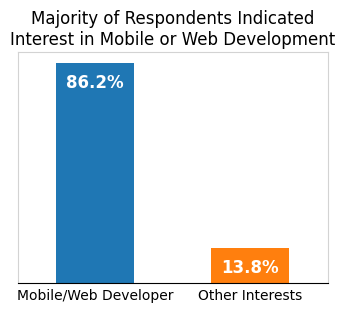

In [10]:
ax = web_and_mobile_ft.plot.bar(figsize=(4, 3),
                           color=['#1f77b4', '#ff7f0e'])
plt.title('Majority of Respondents Indicated\nInterest in Mobile or Web Development')
plt.xticks([0, 1], ['Mobile/Web Developer', 'Other Interests'],
           rotation=0)
plt.xlabel('')
for i, value in enumerate(web_and_mobile_ft):
    ax.text(i,
            value - 4,
            f'{value:.1f}%',
            ha='center',
            va='top',
            color='white',
            fontsize=12,
            fontweight='bold')
ax.tick_params(axis='x', length=0)
plt.yticks([])
ax.spines['left'].set_color('lightgrey')
ax.spines['top'].set_color('lightgrey')
ax.spines['right'].set_color('lightgrey')
plt.show()

The above clearly shows that the majority of respondents in the new coder survey indicated an interest in either Web or Mobile Development (or both).

As most of the courses on offer are about web and modbile development, we are able to conclude that the survey results are representative of the popultation of interest.

## New Coders - Locations and Densities

Examine where new coders are located using the field, `CountryLive` (as opposed to `CountryCitizen` as they may not be the same and ads would have to aimed at where people live, not where they're from).

Concentrate on the results where respondents indicated an area of interest (`JobRoleInterest`) to ensure the sample is still representative.

In [11]:
has_interest_df = survey_df.dropna(subset=['JobRoleInterest']).copy()

In [12]:
country_counts = has_interest_df['CountryLive'].value_counts()
country_pcts = has_interest_df['CountryLive'].value_counts(normalize=True) * 100
countries = pd.DataFrame({'Frequency': country_counts,
                          'Percentages': country_pcts}).reset_index()
countries.head(20)

,CountryLive,Frequency,Percentages
0,United States of America,3125,45.700497
1,India,528,7.721556
2,United Kingdom,315,4.606610
3,Canada,260,3.802281
4,Poland,131,1.915765
5,Brazil,129,1.886517
6,Germany,125,1.828020
7,Australia,112,1.637906
8,Russia,102,1.491664
9,Ukraine,89,1.301550


The above table clearly shows that the most likely market would be United States of America as it is where almost 46% of respondents are located.

The next highest locations were India (7.7%), UK (4.6%) and Canada (3.8%).

On the face of it, it would appear that USA and India would be the locations to choose for advertisement. However, it would be worth considering, as the aim is to be profitable, which markets have learners that are more likely to invest in their studies. Also, if the courses require translation for certain markets, would the cost be prohibitive?

## Spending Money for Learning

Calculate how much money (US dollars) the respondents indicated that they spend per month on their studies. This will be calculated by dividing `MoneyForLearning` by `MonthsProgramming`.

Note that, as some respondents may have only been starting their learning journey when the survey was carried out and responded zero to `MonthsProgramming`. These values (0) will be replaced by 1 so as to avoid 'division by zero' errors.

In [13]:
has_interest_df['MonthlySpend'] = has_interest_df['MoneyForLearning'] / has_interest_df['MonthsProgramming'].apply(lambda x: 1 if x == 0 else x)

In [14]:
has_interest_df['MonthlySpend'].isnull().sum()

np.int64(675)

In [15]:
has_interest_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6992 entries, 1 to 18174
Columns: 137 entries, Age to MonthlySpend
dtypes: float64(106), object(31)
memory usage: 7.4+ MB


There are 675 respondents (out of 6,992 respondents that indicated their location) that report spending no money on their studying.

Focusing on those that did report spending money, look at how much students spent on average per month in the top 4 locations from above.

In [16]:
has_interest_spenders_df = has_interest_df.dropna(subset=['MonthlySpend']).copy()

In [17]:
country_monthly_spend = (has_interest_spenders_df[has_interest_spenders_df['CountryLive']
                                                 .isin(['United States of America',
                                                        'India',
                                                        'United Kingdom',
                                                        'Canada'])].groupby('CountryLive')[['MonthlySpend']]
                         .mean()
                         .sort_values(by='MonthlySpend', ascending=False))
country_monthly_spend

,MonthlySpend
CountryLive,
United States of America,227.997996
India,135.100982
Canada,113.510961
United Kingdom,45.534443


It looks like students in USA spend more per month on studying. The UK looks low compared to the others and it is not clear without further investigation why that should be the case, especially considering that UK and Canada are supposedly 'richer' countries than India.

## Dealing with Extreme Outliers

By examing boxplots of the average monthly spend, identify anomalies and outliers.

As examining and removing outliers is likely to be an iterative process, create a function to draw the boxplots.

In [18]:
top_countries = ['United States of America', 'India', 'United Kingdom', 'Canada']
def show_boxplot(data):
    plt.figure(figsize=(12, 4))
    plt.boxplot(data,
                tick_labels=top_countries,
                patch_artist=True)
    plt.title('Monthly Spend by Selected Country')
    plt.ylabel('Monthly Spend (USD)')
    plt.xlabel('Country')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

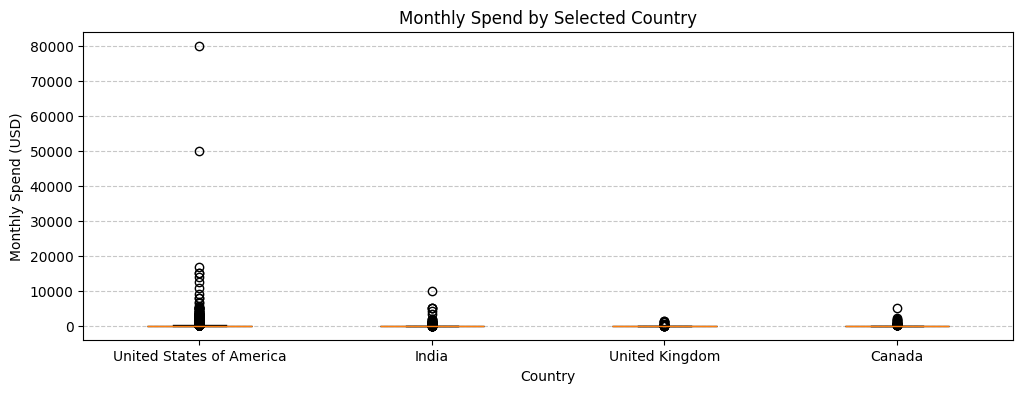

In [19]:
box_data = [has_interest_spenders_df[has_interest_spenders_df['CountryLive'] == country]['MonthlySpend'] for country in top_countries]
show_boxplot(box_data)

It is difficult to glean anything from this diagram because of the two extreme outliers in USA spend per month.

Filter the DataFrame for the top 4 countries to make the following analysis easier...

In [20]:
top_countries_spending = has_interest_spenders_df[has_interest_spenders_df['CountryLive'].isin(top_countries)].copy()

Change the settings so that all columns can be seen without truncation...

In [21]:
pd.options.display.max_columns = len(top_countries_spending.columns)

In [22]:
outlier_query = ((top_countries_spending['CountryLive'] == top_countries[0])
                 & (top_countries_spending['MonthlySpend'] > 30000))
top_countries_spending[outlier_query]

,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,CodeEventFCC,CodeEventGameJam,CodeEventGirlDev,CodeEventHackathons,CodeEventMeetup,CodeEventNodeSchool,CodeEventNone,CodeEventOther,CodeEventRailsBridge,CodeEventRailsGirls,CodeEventStartUpWknd,CodeEventWkdBootcamps,CodeEventWomenCode,CodeEventWorkshops,CommuteTime,CountryCitizen,CountryLive,EmploymentField,EmploymentFieldOther,EmploymentStatus,EmploymentStatusOther,ExpectedEarning,FinanciallySupporting,FirstDevJob,Gender,GenderOther,HasChildren,HasDebt,HasFinancialDependents,HasHighSpdInternet,HasHomeMortgage,HasServedInMilitary,HasStudentDebt,HomeMortgageOwe,HoursLearning,ID.x,ID.y,Income,IsEthnicMinority,IsReceiveDisabilitiesBenefits,IsSoftwareDev,IsUnderEmployed,JobApplyWhen,JobInterestBackEnd,JobInterestDataEngr,JobInterestDataSci,JobInterestDevOps,JobInterestFrontEnd,JobInterestFullStack,JobInterestGameDev,JobInterestInfoSec,JobInterestMobile,JobInterestOther,JobInterestProjMngr,JobInterestQAEngr,JobInterestUX,JobPref,JobRelocateYesNo,JobRoleInterest,JobWherePref,LanguageAtHome,MaritalStatus,MoneyForLearning,MonthsProgramming,NetworkID,Part1EndTime,Part1StartTime,Part2EndTime,Part2StartTime,PodcastChangeLog,PodcastCodeNewbie,PodcastCodePen,PodcastDevTea,PodcastDotNET,PodcastGiantRobots,PodcastJSAir,PodcastJSJabber,PodcastNone,PodcastOther,PodcastProgThrowdown,PodcastRubyRogues,PodcastSEDaily,PodcastSERadio,PodcastShopTalk,PodcastTalkPython,PodcastTheWebAhead,ResourceCodecademy,ResourceCodeWars,ResourceCoursera,ResourceCSS,ResourceEdX,ResourceEgghead,ResourceFCC,ResourceHackerRank,ResourceKA,ResourceLynda,ResourceMDN,ResourceOdinProj,ResourceOther,ResourcePluralSight,ResourceSkillcrush,ResourceSO,ResourceTreehouse,ResourceUdacity,ResourceUdemy,ResourceW3S,SchoolDegree,SchoolMajor,StudentDebtOwe,YouTubeCodeCourse,YouTubeCodingTrain,YouTubeCodingTut360,YouTubeComputerphile,YouTubeDerekBanas,YouTubeDevTips,YouTubeEngineeredTruth,YouTubeFCC,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston,MonthlySpend
2478,38.0,1.0,0.0,1.0,NaN,1.0,NaN,"between 100,000 and 1 million",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,United States of America,NaN,NaN,Not working and not looking for work,NaN,100000.0,NaN,NaN,trans,NaN,NaN,1.0,0.0,1.0,0.0,0.0,1.0,NaN,40.0,b84e33311d235660ad1b7a918d7d7df4,b3229f43317af29a4d23734f9d543222,NaN,0.0,0.0,0.0,NaN,Within 7 to 12 months,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,work for a nonprofit,NaN,"Front-End Web Developer, Full-Stack Web Deve...",from home,English,"single, never married",100000.0,2.0,befcbda814,2017-03-10 23:30:16,2017-03-10 23:26:33,2017-03-10 23:31:50,2017-03-10 23:30:19,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,1.0,"some college credit, no degree",NaN,48000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50000.0
14024,45.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,United States of America,NaN,NaN,Not working but looking for work,NaN,30000.0,NaN,NaN,male,NaN,NaN,1.0,0.0,1.0,0.0,0.0,1.0,NaN,20.0,11d884a40e5662ef57566556206b7754,4f77cc788154cb155fb513ece8ea40da,NaN,0.0,0.0,0.0,NaN,I'm already applying,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,work for a nonprofit,0.0,"Back-End Web Developer, Front-End Web Develo...",in an office with other developers,English,"single, never married",80000.0,1.0,b01f8f18a7,2017-03-16 23:14:34,2017-03-16 23:09:32,2017-03-16 23:16:45,2017-03-16 23:14:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bachel

Examining the above, it seems unlikely that these monthly spend amounts are correct, in terms of the question asked at least. These records shall therefore be removed and the boxplots recreated.

In [23]:
top_countries_spending = top_countries_spending[~outlier_query] 

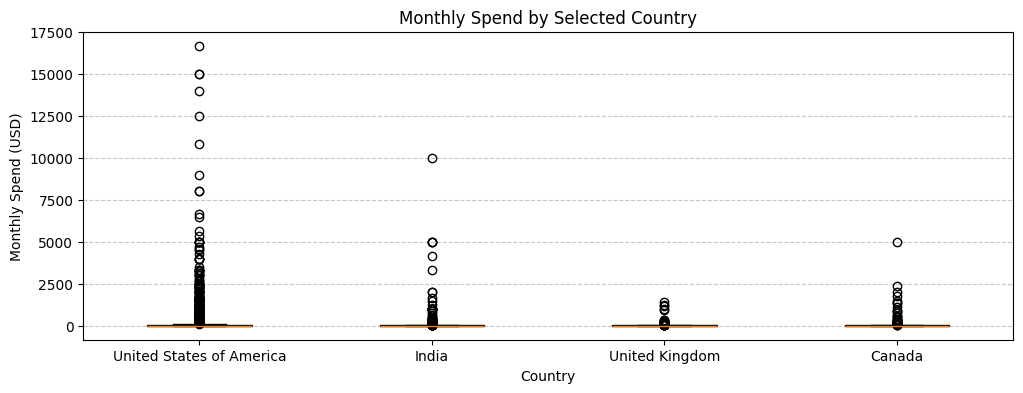

In [24]:
box_data = [top_countries_spending[top_countries_spending['CountryLive'] == country]['MonthlySpend'] for country in top_countries]
show_boxplot(box_data)

There are still outliers in USA monthly spend that are above even the most extreme outliers from the other countries.

In [25]:
outlier_query = ((top_countries_spending['CountryLive'] == top_countries[0])
                 & (top_countries_spending['MonthlySpend'] > 10000))
top_countries_spending[outlier_query]

,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,CodeEventFCC,CodeEventGameJam,CodeEventGirlDev,CodeEventHackathons,CodeEventMeetup,CodeEventNodeSchool,CodeEventNone,CodeEventOther,CodeEventRailsBridge,CodeEventRailsGirls,CodeEventStartUpWknd,CodeEventWkdBootcamps,CodeEventWomenCode,CodeEventWorkshops,CommuteTime,CountryCitizen,CountryLive,EmploymentField,EmploymentFieldOther,EmploymentStatus,EmploymentStatusOther,ExpectedEarning,FinanciallySupporting,FirstDevJob,Gender,GenderOther,HasChildren,HasDebt,HasFinancialDependents,HasHighSpdInternet,HasHomeMortgage,HasServedInMilitary,HasStudentDebt,HomeMortgageOwe,HoursLearning,ID.x,ID.y,Income,IsEthnicMinority,IsReceiveDisabilitiesBenefits,IsSoftwareDev,IsUnderEmployed,JobApplyWhen,JobInterestBackEnd,JobInterestDataEngr,JobInterestDataSci,JobInterestDevOps,JobInterestFrontEnd,JobInterestFullStack,JobInterestGameDev,JobInterestInfoSec,JobInterestMobile,JobInterestOther,JobInterestProjMngr,JobInterestQAEngr,JobInterestUX,JobPref,JobRelocateYesNo,JobRoleInterest,JobWherePref,LanguageAtHome,MaritalStatus,MoneyForLearning,MonthsProgramming,NetworkID,Part1EndTime,Part1StartTime,Part2EndTime,Part2StartTime,PodcastChangeLog,PodcastCodeNewbie,PodcastCodePen,PodcastDevTea,PodcastDotNET,PodcastGiantRobots,PodcastJSAir,PodcastJSJabber,PodcastNone,PodcastOther,PodcastProgThrowdown,PodcastRubyRogues,PodcastSEDaily,PodcastSERadio,PodcastShopTalk,PodcastTalkPython,PodcastTheWebAhead,ResourceCodecademy,ResourceCodeWars,ResourceCoursera,ResourceCSS,ResourceEdX,ResourceEgghead,ResourceFCC,ResourceHackerRank,ResourceKA,ResourceLynda,ResourceMDN,ResourceOdinProj,ResourceOther,ResourcePluralSight,ResourceSkillcrush,ResourceSO,ResourceTreehouse,ResourceUdacity,ResourceUdemy,ResourceW3S,SchoolDegree,SchoolMajor,StudentDebtOwe,YouTubeCodeCourse,YouTubeCodingTrain,YouTubeCodingTut360,YouTubeComputerphile,YouTubeDerekBanas,YouTubeDevTips,YouTubeEngineeredTruth,YouTubeFCC,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston,MonthlySpend
3930,31.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,United States of America,NaN,NaN,Not working and not looking for work,NaN,100000.0,NaN,NaN,male,NaN,NaN,1.0,0.0,1.0,0.0,0.0,1.0,NaN,50.0,e1d790033545934fbe5bb5b60e368cd9,7cf1e41682462c42ce48029abf77d43c,NaN,1.0,0.0,0.0,NaN,Within the next 6 months,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,work for a startup,1.0,"DevOps / SysAdmin, Front-End Web Developer...",no preference,English,married or domestic partnership,65000.0,6.0,75759e5a1c,2017-03-13 10:06:46,2017-03-13 09:56:13,2017-03-13 10:10:00,2017-03-13 10:06:50,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,reactivex.io/learnrx/ & jafar husain,NaN,NaN,1.0,NaN,NaN,NaN,NaN,bachelor's degree,Biology,40000.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,various conf presentations,NaN,NaN,10833.333333
6805,46.0,1.0,1.0,1.0,Sabio.la,0.0,NaN,"between 100,000 and 1 million",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,United States of America,NaN,NaN,Not working but looking for work,NaN,70000.0,NaN,NaN,male,NaN,NaN,1.0,0.0,1.0,0.0,0.0,1.0,NaN,45.0,69096aacf4245694303cf8f7ce68a63f,4c56f82a348836e76dd90d18a3d5ed88,NaN,1.0,0.0,0.0,NaN,Within the next 6 months,NaN,1.0,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,work for a multinational corporation,1.0,"Full-Stack Web Developer, Game Developer, Pr...",no preference,English,married or domestic partnership,15000.0,1.0,53d13b58e9,2017-03-21 20:13:08,2017-03-21 20:10:25,2017-03-21 20:14:36,2017-03-21 20:13:11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,

Apart from 1 respondent that attended a bootcamp, there isn't an obvious explanation for the disproportionate monthly spend. As the amounts in question are unlikely to be representative of the target learners, they shall also now be excluded.

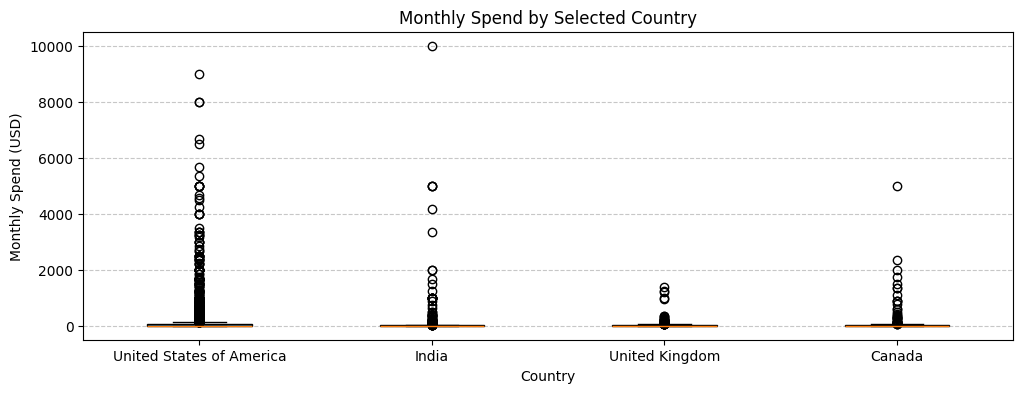

In [26]:
top_countries_spending = top_countries_spending[~outlier_query]
box_data = [top_countries_spending[top_countries_spending['CountryLive'] == country]['MonthlySpend'] for country in top_countries]
show_boxplot(box_data)

Look at the outliers over $3,000 monthly spend in the other 3 countries.

In [27]:
outlier_query = ((top_countries_spending['CountryLive'] != top_countries[0])
                 & (top_countries_spending['MonthlySpend'] > 3000))
top_countries_spending[outlier_query]

,Age,AttendedBootcamp,BootcampFinish,BootcampLoanYesNo,BootcampName,BootcampRecommend,ChildrenNumber,CityPopulation,CodeEventConferences,CodeEventDjangoGirls,CodeEventFCC,CodeEventGameJam,CodeEventGirlDev,CodeEventHackathons,CodeEventMeetup,CodeEventNodeSchool,CodeEventNone,CodeEventOther,CodeEventRailsBridge,CodeEventRailsGirls,CodeEventStartUpWknd,CodeEventWkdBootcamps,CodeEventWomenCode,CodeEventWorkshops,CommuteTime,CountryCitizen,CountryLive,EmploymentField,EmploymentFieldOther,EmploymentStatus,EmploymentStatusOther,ExpectedEarning,FinanciallySupporting,FirstDevJob,Gender,GenderOther,HasChildren,HasDebt,HasFinancialDependents,HasHighSpdInternet,HasHomeMortgage,HasServedInMilitary,HasStudentDebt,HomeMortgageOwe,HoursLearning,ID.x,ID.y,Income,IsEthnicMinority,IsReceiveDisabilitiesBenefits,IsSoftwareDev,IsUnderEmployed,JobApplyWhen,JobInterestBackEnd,JobInterestDataEngr,JobInterestDataSci,JobInterestDevOps,JobInterestFrontEnd,JobInterestFullStack,JobInterestGameDev,JobInterestInfoSec,JobInterestMobile,JobInterestOther,JobInterestProjMngr,JobInterestQAEngr,JobInterestUX,JobPref,JobRelocateYesNo,JobRoleInterest,JobWherePref,LanguageAtHome,MaritalStatus,MoneyForLearning,MonthsProgramming,NetworkID,Part1EndTime,Part1StartTime,Part2EndTime,Part2StartTime,PodcastChangeLog,PodcastCodeNewbie,PodcastCodePen,PodcastDevTea,PodcastDotNET,PodcastGiantRobots,PodcastJSAir,PodcastJSJabber,PodcastNone,PodcastOther,PodcastProgThrowdown,PodcastRubyRogues,PodcastSEDaily,PodcastSERadio,PodcastShopTalk,PodcastTalkPython,PodcastTheWebAhead,ResourceCodecademy,ResourceCodeWars,ResourceCoursera,ResourceCSS,ResourceEdX,ResourceEgghead,ResourceFCC,ResourceHackerRank,ResourceKA,ResourceLynda,ResourceMDN,ResourceOdinProj,ResourceOther,ResourcePluralSight,ResourceSkillcrush,ResourceSO,ResourceTreehouse,ResourceUdacity,ResourceUdemy,ResourceW3S,SchoolDegree,SchoolMajor,StudentDebtOwe,YouTubeCodeCourse,YouTubeCodingTrain,YouTubeCodingTut360,YouTubeComputerphile,YouTubeDerekBanas,YouTubeDevTips,YouTubeEngineeredTruth,YouTubeFCC,YouTubeFunFunFunction,YouTubeGoogleDev,YouTubeLearnCode,YouTubeLevelUpTuts,YouTubeMIT,YouTubeMozillaHacks,YouTubeOther,YouTubeSimplilearn,YouTubeTheNewBoston,MonthlySpend
1728,24.0,0.0,NaN,NaN,NaN,NaN,NaN,"between 100,000 and 1 million",NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,India,India,NaN,NaN,A stay-at-home parent or homemaker,NaN,70000.0,NaN,NaN,male,NaN,NaN,0.0,0.0,1.0,NaN,0.0,NaN,NaN,30.0,d964ec629fd6d85a5bf27f7339f4fa6d,950a8cf9cef1ae6a15da470e572b1b7a,NaN,0.0,0.0,0.0,NaN,Within the next 6 months,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,work for a startup,1.0,"User Experience Designer, Mobile Developer...",in an office with other developers,Bengali,"single, never married",20000.0,4.0,38d312a990,2017-03-10 10:22:34,2017-03-10 10:17:42,2017-03-10 10:24:38,2017-03-10 10:22:40,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,bachelor's degree,Computer Programming,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.000000
1755,20.0,0.0,NaN,NaN,NaN,NaN,NaN,more than 1 million,NaN,NaN,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,India,India,NaN,NaN,Not working and not looking for work,NaN,100000.0,NaN,NaN,male,NaN,NaN,0.0,0.0,1.0,NaN,0.0,NaN,NaN,10.0,811bf953ef546460f5436fcf2baa532d,81e2a4cab0543e14746c4a20ffdae17c,NaN,0.0,0.0,0.0,NaN,I haven't decided,NaN,1.0,NaN,1.0,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,work for a multinational corporation,1.0,"Information Security, Full-Stack Web Developer...",no preference,Hindi,"single, never married",50000.0,15.0,4611a76b60,2017-03-10 10:48:31,2017-03-10 10:42:29,2017-03-10 10:51:37,2017-03-10 10:48:38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,1.0,1.0,bachelor's degree,Computer Science,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,N

Again, there is no concrete evidence to suggest that these monthly amounts are incorrect, however, given that some of these respondents are out of work, are not looking for work or don't have English as their native language, they can also be excluded as non representative of the target learners.

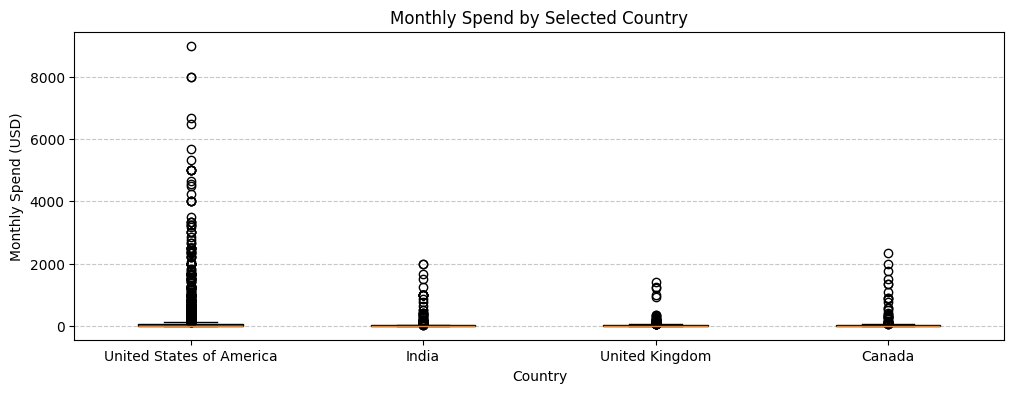

In [28]:
top_countries_spending = top_countries_spending[~outlier_query]
box_data = [top_countries_spending[top_countries_spending['CountryLive'] == country]['MonthlySpend'] for country in top_countries]
show_boxplot(box_data)

In [29]:
country_monthly_spend = (top_countries_spending.groupby('CountryLive')[['MonthlySpend']]
                         .mean()
                         .sort_values(by='MonthlySpend', ascending=False))
country_monthly_spend

,MonthlySpend
CountryLive,
United States of America,155.459187
Canada,93.065400
India,65.758763
United Kingdom,45.534443


These data still contain a significant number of outliers, probably showing that the fields used (or the questions asked) do not really align with the question at hand that reliably.

Calculate and remove outliers that are above or below 1.5 times the interquartile range from the mean, out of interest, to see whether a similar picture is revealed.

In [30]:
country_spend_expanded = (top_countries_spending.groupby('CountryLive')['MonthlySpend']
                          .agg([
                              ('Mean Monthly Spend', 'mean'),
                              ('25th Percentile', lambda x: x.quantile(0.25)),
                              ('Median', lambda x: x.quantile(0.5)),
                              ('75th Percentile', lambda x: x.quantile(0.75)),
                              ('Count', 'count')
                          ]).sort_values(by='Mean Monthly Spend', ascending=False))
country_spend_expanded['iqr'] = country_spend_expanded['75th Percentile'] - country_spend_expanded['25th Percentile']
country_spend_expanded['Upper Bound'] = country_spend_expanded['75th Percentile'] + (1.5 * country_spend_expanded['iqr'])
country_spend_expanded['Lower Bound'] = country_spend_expanded['25th Percentile'] - (1.5 * country_spend_expanded['iqr'])
country_spend_expanded

,Mean Monthly Spend,25th Percentile,Median,75th Percentile,Count,iqr,Upper Bound,Lower Bound
CountryLive,,,,,,,,
United States of America,155.459187,0.0,3.333333,50.000000,2925,50.000000,125.000000,-75.000
Canada,93.065400,0.0,0.000000,25.000000,239,25.000000,62.500000,-37.500
India,65.758763,0.0,0.000000,12.500000,457,12.500000,31.250000,-18.750
United Kingdom,45.534443,0.0,0.000000,20.416667,279,20.416667,51.041667,-30.625


In [31]:
adj_top_countries = top_countries_spending[
    ((top_countries_spending['CountryLive'] == 'United States of America') & (top_countries_spending['MonthlySpend'] <= 125)) |
    ((top_countries_spending['CountryLive'] == 'Canada') & (top_countries_spending['MonthlySpend'] <= 62.5)) |
    ((top_countries_spending['CountryLive'] == 'India') & (top_countries_spending['MonthlySpend'] <= 32.25)) |
    ((top_countries_spending['CountryLive'] == 'United Kingdom') & (top_countries_spending['MonthlySpend'] <= 51.04))
].copy()

In [32]:
adj_monthly_spend = (adj_top_countries.groupby('CountryLive')[['MonthlySpend']]
                         .mean()
                         .sort_values(by='MonthlySpend', ascending=False))
adj_monthly_spend

,MonthlySpend
CountryLive,
United States of America,14.428544
Canada,6.826765
United Kingdom,6.096647
India,2.530940


In [33]:
adj_top_countries['CountryLive'].value_counts()

CountryLive
United States of America    2485
India                        371
United Kingdom               234
Canada                       202
Name: count, dtype: int64

This shows that the spend, even after removing outliers as defined above, is far bigger in the United States of America than elsewhere. The volume of respondents from there compared to other regions may also indicate that advertisement investment would be more valuable. There does not seem to be enough evidence to suggest that investing in the other regions would be profitable and it is not clear that there is a 'second' region so far.

## Choosing the Two Best Markets

Based on the analysis so far, it is clear that USA is worth advertising and that the volume of new coders and the average spend suggest that the majority of the budget should be invested there.

The information available doesn't make it clear that investing in another market, even proportionally is a simple choice. On the one hand, before removing the outliers, India looks like it would have a good balance of new coders and willingness to invest in their education but looking at the monthly spend more closely centered around the mean, Canada and UK look to be similar markets.

Therefore, it would be worth further investigation by a marketing department with greater domain knowledge to assess both the second or more countries to advertise in as well as the split in budget between those regions.